# Figure showing how many years historically were in the CI

In [78]:
import xarray as xr
from xarray.groupers import SeasonResampler
import xesmf as xe
import numpy as np
import pandas as pd 
import geopandas as gpd
import os
import glob
import re
import string
from matplotlib import pyplot as plt
from matplotlib import patches as mpatches
import matplotlib as mpl
from cartopy import crs as ccrs
import cmocean
from dask.diagnostics import ProgressBar
from tqdm.notebook import tqdm
from numba import jit as njit
from distributed import Client

from funcs_support import get_params,get_filepaths, utility_print, utility_save, load_data, area_mean
from funcs_aux import get_landmask

dir_list = get_params()

mpl.font_manager.fontManager.addfont(dir_list['aux'] + "fonts/Lato-Regular.ttf")
mpl.font_manager.fontManager.addfont(dir_list['aux'] + "fonts/Lato-Bold.ttf")

mpl.rcParams.update({
    "font.family": "Lato",
})

subplot_lettering = string.ascii_lowercase #string.ascii_lowercase

In [75]:
client = Client()
display(client)

/home/kschwarz/.conda/envs/aa_thresh/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44645 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:44645/status,
Dashboard: http://127.0.0.1:44645/status,Workers: 8
Total threads: 48,Total memory: 503.54 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45669,Workers: 0
Dashboard: http://127.0.0.1:44645/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44651,Total threads: 6
Dashboard: http://127.0.0.1:40251/status,Memory: 62.94 GiB
Nanny: tcp://127.0.0.1:37837,


In [79]:
# Trigger threshold
aa_trigger = 0.2
# Random seed for bootstraps
rng = np.random.default_rng()
# How many years / block
samp_sizes = np.arange(1,20)
# How many bootstrap draws
ndraws = 1000

# Set up filepaths
df = get_filepaths()

# Variables / bootstrap dimension setup
boot_dim = 'year'
var = 'pr'

# Which data to use
# GPCP, CHIRPS, or NCEP-CFSv2 / NCEP-CFSv2-ensmean
proc_source = 'NCEP-CFSv2-ensmean' 
#proc_source = 'GPCP'

# Set output filenames
load_fns = {'threshs':dir_list['tmp']+'pr-trigger-threshs_year_'+proc_source+'.zarr',
              'seasmask':dir_list['aux']+'seasmask_CHIRPS.zarr'}

In [80]:
# Load calculated trigger thresholds
threshs = xr.open_zarr(load_fns['threshs'])

In [81]:
# Get landmask
landmask = get_landmask(threshs,lm_source='ne110')

# Get country borders
gdf = gpd.read_file(dir_list['aux']+'geo_data/ne_10m_admin_0_countries_iso/ne_10m_admin_0_countries_iso.shp')

# Get mask for if there's an active season locally
active_seasons = xr.open_zarr(load_fns['seasmask'])
# Regrid seasonmask to trigger threshold grid
rgrd = xe.Regridder(active_seasons,threshs,'conservative')
active_seasons_rg = rgrd(active_seasons)
active_seasons_rg = active_seasons_rg.sel(lat=threshs.lat.values)

lat/lon bounds not found in dataset; they will be created.


In [82]:
# Load raw data
ds,fn = load_data(proc_source,return_loadfn=True)
fn_seasmeans = re.sub(r'\_Amon\_','_seasavg_',re.sub(dir_list['raw'],dir_list['proc'],fn))

In [83]:
#-------------------------------------
# Get threshold-based dry season mask
#-------------------------------------
seas_thresh = 0.5 # mm/day

# Load data
dsm = load_data(proc_source,data='seasavg')

# Get boolean mask for threshold exceedence
dry_thresh = dsm.pr.mean('year')>seas_thresh



In [84]:
threshs['triggrange_bnds'] = xr.concat([threshs['triggthresh'].quantile(0.025,dim='draw'),
                                        threshs['triggthresh'].quantile(0.975,dim='draw')],
                                       dim='bnds')

In [85]:
dsm['within_ci'] = ((dsm['pr'] >= threshs['triggrange_bnds'].isel(bnds=0)) & 
                     (dsm['pr'] <= threshs['triggrange_bnds'].isel(bnds=1))).compute()

In [86]:
threshs['nyears_within_ci'] = dsm['within_ci'].sum('year')
threshs['propyears_within_ci'] = threshs['nyears_within_ci']/dsm.sizes['year']

/home/kschwarz/.conda/envs/aa_thresh/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 13.44 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/kschwarz/projects/forecast_uncertainty/2. figures/NCEP-CFSv2-ensmean_propyears_diag_blength5.pdf saved!
/home/kschwarz/projects/forecast_uncertainty/2. figures/NCEP-CFSv2-ensmean_propyears_diag_blength5.png saved!


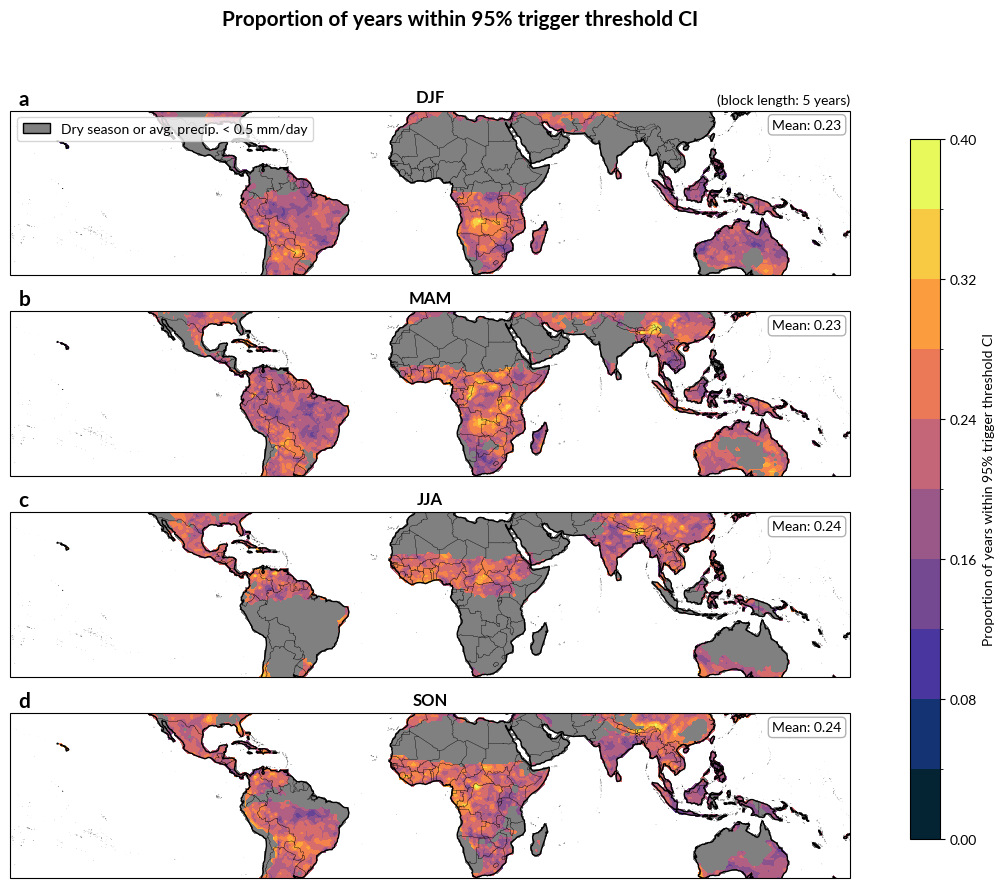

In [90]:
seas_thresh = 0.5 # mm/day

fig = plt.figure(figsize=(12,10))

block_length = 5

save_fig = True
output_fn = f'{dir_list['figs']}{proc_source}_propyears_diag_blength{block_length}'

var = 'propyears_within_ci'

cbar_params = {'propyears_within_ci':{'vmin':0,'vmax':0.4,'cmap':cmocean.cm.thermal,'levels':11},
               'triggrange':{'vmin':0,'vmax':5,'cmap':cmocean.cm.amp,'levels':11},
               'triggrange_cv_log':{'vmin':-1,'vmax':1,'cmap':mpl.colormaps['berlin'],'levels':11},
               'triggrange_cv_meanpr':{'vmin':0,'vmax':1,'cmap':cmocean.cm.amp,'levels':11}}

labels = {'propyears_within_ci':'Proportion of years within 95% trigger threshold CI',
          'triggrange':'range of bootstrapped trigger thresholds [mm/day]',
          'triggrange_cv_log':'range / Mean of bootstrapped trigger thresholds',
          'triggrange_cv_meanpr':'Trigger range as fraction of mean P'}


subset_params = {'lat':slice(-35,35),'lon':slice(-180,180)}

seas_mask = (active_seasons_rg.seasmask.sel(**subset_params) & 
                   dry_thresh).where(landmask).compute()

for seas_idx,seas in enumerate(['DJF','MAM','JJA','SON']):
    ax = plt.subplot(4,1,seas_idx+1,projection=ccrs.PlateCarree())

    plot_data = threshs[var].sel(season=seas,block_nyears=block_size,**subset_params)
    # Subset to land only
    plot_data = plot_data.where(landmask)

    # Plot
    plot_data.plot.contourf(transform=ccrs.PlateCarree(),**cbar_params[var],
                            add_colorbar=False)

    # Grey out regions without an active rainy season or that are generally 
    # too dry
    seas_mask.sel(season=seas).plot.contourf(levels=[-0.5, 0.5, 1.5],
                                 colors=['grey','none'],
                                 hatches=[None, None],
                                 transform=ccrs.PlateCarree(),
                                 add_colorbar=False)

    ax.coastlines()
    ax.set_title(seas,fontweight='bold',fontsize=12)

    # Plot mean text
    ax.annotate(f'Mean: {str(np.round(area_mean(plot_data.where(seas_mask.sel(season=seas))).values,2))}',
                (0.99,0.95),
                xycoords = 'axes fraction',
                ha='right',va='top',
                bbox={'boxstyle':'round','alpha':0.3,
                      'fc':'w'})
    
    # Country borders
    # Add to plot (subset_params in slice format)
    gdf.cx[subset_params['lon'],subset_params['lat']].plot(ax=ax,facecolor='none',edgecolor='k',
                                                       linestyle='-',linewidth=0.15,
                                                       transform=ccrs.PlateCarree())
    ax.set_extent([subset_params['lon'].start,
                   subset_params['lon'].stop,
                   subset_params['lat'].start,
                   subset_params['lat'].stop])

    if seas_idx == 0:
        ax.legend(handles=[mpatches.Patch(facecolor='grey',edgecolor='k',
                                          label=f'Dry season or avg. precip. < {str(seas_thresh)} mm/day')],loc='upper left')
        ax.annotate(f'(block length: {block_length} years)',
                        (1,1.025),xycoords = 'axes fraction',
                        ha='right',va='bottom',
                        fontsize=10)
    ax.annotate(subplot_lettering[seas_idx],(0.01,1.01),xycoords = 'axes fraction',
                        fontweight='bold',fontsize=15,va='bottom')

fig.subplots_adjust(right=0.825)
cax = fig.add_axes([0.875, 0.15, 0.025, 0.7])
levels = mpl.ticker.MaxNLocator(nbins=cbar_params[var]['levels']).tick_values(cbar_params[var]['vmin'],cbar_params[var]['vmax'])
norm = mpl.colors.BoundaryNorm(levels, ncolors=cbar_params[var]['cmap'].N, clip=True)
sm = plt.cm.ScalarMappable(cmap=cbar_params[var]['cmap'],norm=norm)
plt.colorbar(sm,cax=cax,label=labels[var])


plt.suptitle(labels[var],fontweight='bold',fontsize=15)
if save_fig:
    utility_print(output_fn)